<a href="https://colab.research.google.com/github/sritejavarma11/Potato-Leaf-Disease-Classification/blob/main/ConvNeXtTiny(CNN)%2BTransformer%2BMLP_Classifier_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q tensorflow
!pip install -U keras-cv --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 48.3 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import keras_cv
import os

DATA_DIR = '/content/drive/MyDrive/PlantVillage'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
NUM_CLASSES = 3


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Optional: improve performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


Found 5403 files belonging to 3 classes.
Found 763 files belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras import layers, Model

# Load ConvNeXtTiny backbone
convnext = ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
    pooling=None
)
convnext.trainable = False


# 1. Transformer Encoder Block
def transformer_block(inputs, num_heads=4, ff_dim=256):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim)(x, x)
    x = layers.Add()([x, inputs])
    x_skip = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(ff_dim, activation='relu')(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return layers.Add()([x, x_skip])

# 2. Build the Hybrid Model
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = convnext(inputs, training=False)
x = layers.Reshape((-1, x.shape[-1]))(x)  # Flatten spatial dimensions

x = transformer_block(x)  # Add transformer block
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

# 3. Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Show the model summary
model.summary()


111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny       │ (None, 7, 7, 768) │ 27,820,128 │ input_layer_5[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 49, 768)   │          0 │ convnext_tiny[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 768)   │      1,536 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 768)   │  3,149,568 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 49, 768)   │          0 │ multi_head_atten… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 768)   │      1,536 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 49, 256)   │    196,864 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 49, 768)   │    197,376 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 49, 768)   │          0 │ dense_1[0][0],    │
│                     │                   │            │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ add_19[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 768)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     98,432 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        387 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,465,827 (120.03 MB)

 Trainable params: 3,645,699 (13.91 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

In [ ]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1003s 6s/step - accuracy: 0.8085 - loss: 0.5190 - val_accuracy: 0.9646 - val_loss: 0.1171
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 26s 154ms/step - accuracy: 0.9534 - loss: 0.1471 - val_accuracy: 0.9659 - val_loss: 0.1227
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 40s 147ms/step - accuracy: 0.9822 - loss: 0.0552 - val_accuracy: 0.9751 - val_loss: 0.0774
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.9893 - loss: 0.0317 - val_accuracy: 0.9279 - val_loss: 0.3589
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.9815 - loss: 0.0682 - val_accuracy: 0.9659 - val_loss: 0.1424
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 40s 147ms/step - accuracy: 0.9902 - loss: 0.0321 - val_accuracy: 0.9790 - val_loss: 0.1599
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 44s 165ms/step - accuracy: 0.9883 - loss: 0.0435 - val_accuracy: 0.9738 - val_loss: 0.0990
Epoch 8/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 27s 161ms/step - accuracy: 0.9918 - loss: 0.

In [ ]:
model.evaluate(val_ds)
model.save('/content/drive/MyDrive/potato_hybrid_modell.h5')


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.9786 - loss: 0.2035


In [ ]:
from keras.saving import save_model
save_model(model, "modell.keras")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


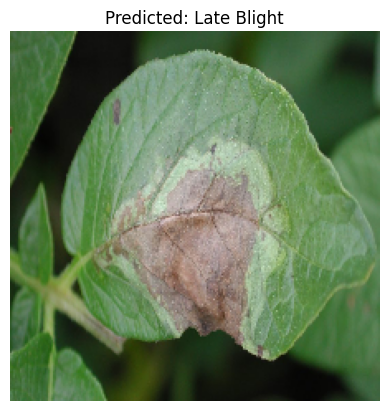

In [ ]:
# STEP 2: Set the correct image path from Drive
IMG_PATH = "/content/drive/MyDrive/DataSetPotato/Testing/LateBlight.jpg"  # <--- update to your actual file

# STEP 3: Use the image size the model was trained on
IMG_SIZE = (224, 224)  # <-- your model expects 224x224 input

# STEP 4: Define class names
class_names = ['Early Blight', 'Late Blight', 'Healthy']

# STEP 5: Load and preprocess the image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

img = image.load_img(IMG_PATH, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

# STEP 6: Make prediction
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]

# STEP 7: Display the result
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()


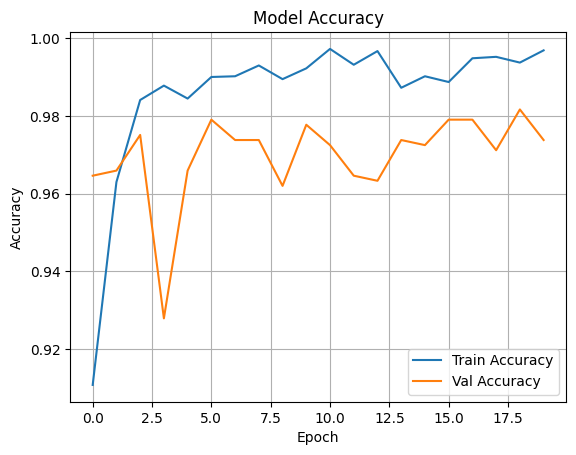

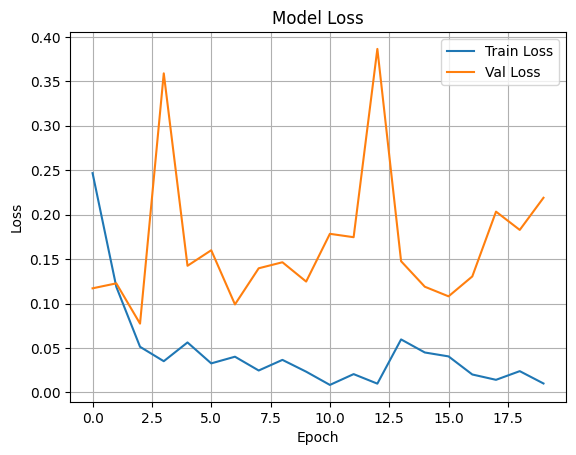

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

# Define class names in the correct order
class_names = ['Early Blight', 'Late Blight', 'Healthy']
NUM_CLASSES = len(class_names)

# Step 1: Collect all images and labels from the validation set
X_val = []
y_val = []

for batch_images, batch_labels in val_ds:
    X_val.append(batch_images.numpy())
    y_val.append(batch_labels.numpy())

X_val = np.vstack(X_val)
y_val = np.vstack(y_val)

# Step 2: Get predictions from the model
y_true = np.argmax(y_val, axis=1)
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Step 3: Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# Step 4: Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Step 5: ROC Curves for Each Class
y_true_onehot = y_val  # Already one-hot encoded
fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#


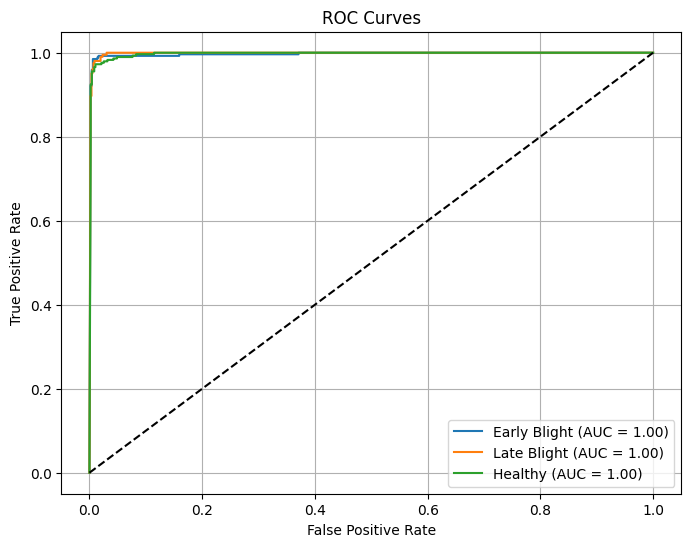

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

NUM_CLASSES = len(class_names)
fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_val[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


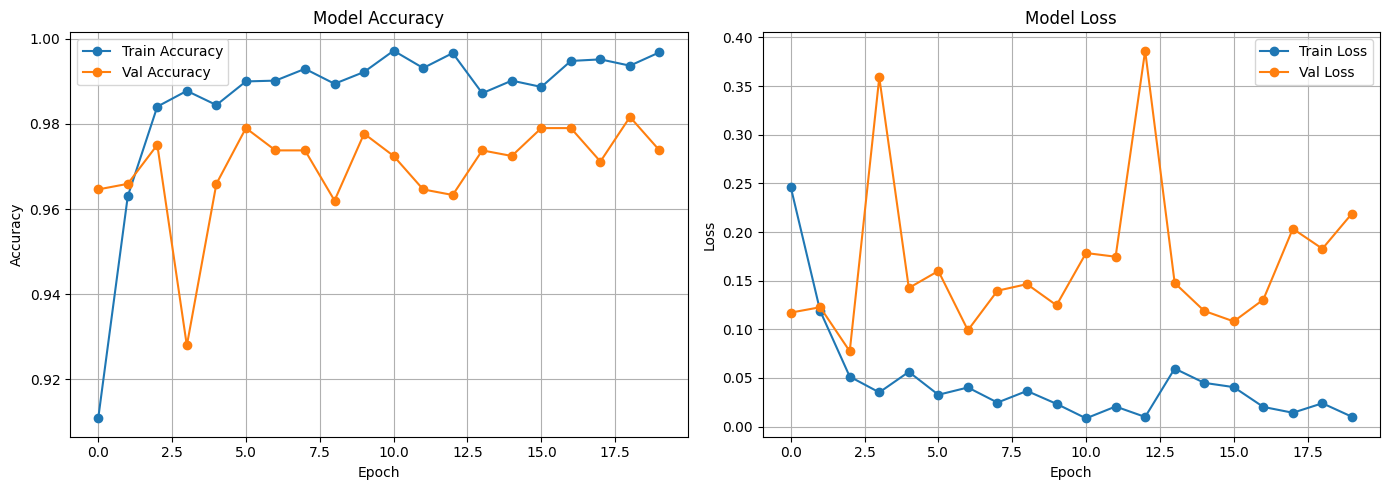

In [ ]:
# Plot training & validation accuracy/loss
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import pandas as pd

# Count occurrences
val_labels = np.argmax(y_val, axis=1)
df = pd.DataFrame({'label': val_labels})
df['label'] = df['label'].map(dict(enumerate(class_names)))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='viridis')
plt.title("Validation Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(axis='y')
plt.show()
